In [2]:
using Pkg
Pkg.activate(".")

  Activating project at `~/Desktop/Waterloo/Masters/LOO_PIT_Manual/Capse_Planck`


In [3]:
# Pkg.add("Random")
# Pkg.add("LinearAlgebra")
# Pkg.add("Turing")
# Pkg.add("PosteriorStats")
# Pkg.add("Distributions")
# Pkg.add("PDMats")
# Pkg.add("LogExpFunctions")
# Pkg.add("Plots")
# Pkg.add("ArviZ")
# Pkg.add("HypothesisTests)

In [4]:
using Random
using LinearAlgebra
using Turing
using PosteriorStats
using Distributions
using PDMats
using LogExpFunctions
using Plots
using ArviZ
using HypothesisTests

### Model Set Up

In [5]:
# Define the Turing model
@model function myfoo(SL, x)
    a ~ Uniform(-10, 10)
    b ~ Uniform(-10, 10)
    μ = a .* x .+ b
    S = Symmetric(SL * SL')
    # Multivariate Normal observation
    y ~ MvNormal(μ, PDMat(Cholesky(SL)))
    return y
end

# Setup synthetic data
Random.seed!(1234)
n = 100
R = rand(LKJCholesky(n, 1))
s = rand(filldist(truncated(TDist(7); lower=0), n))
SL = LowerTriangular(Diagonal(s) * R.L) + 0.2I
S = Symmetric(SL * SL')

x = Array(LinRange(-7, 7, n))
a_true = 1.0
b_true = -3.0
y = rand(MvNormal(a_true .* x .+ b_true, S))

100-element Vector{Float64}:
 -10.69527063150974
 -10.252760841752925
  -9.847087372275812
 -10.560420005646623
  -9.22761985592522
 -11.239895507038792
  -9.411066829212661
  -8.323260236398404
  -9.038885967956297
  -9.149043102923361
  -8.483309180339113
  -8.147104428406067
  -8.123725708107965
   ⋮
   1.9860515660889706
   2.4292640049152223
   6.966580663385802
   5.139938339042853
   3.046206819297155
   4.7766993401301665
   2.9736980732526366
   2.7930330090236244
   4.246023435220193
   3.7467658593142277
   3.3706198309340896
   6.491405961258838

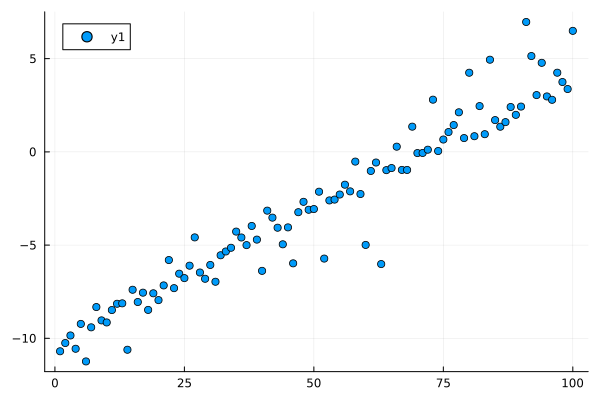

In [6]:
scatter(y)

### Running Chains

In [7]:
num_steps = 2000
num_chains = 8

# Sample from the model using 8 parallel chains
chns = sample(myfoo(SL, x) | (; y), NUTS(), MCMCThreads(), num_steps, num_chains)

# Generate posterior predictions: stochastic realizations from the likelihood
y_pred = predict(myfoo(SL, x), chns)

┌ Info: Found initial step size
└   ϵ = 0.0015625
┌ Info: Found initial step size
└   ϵ = 0.0015625
┌ Info: Found initial step size
└   ϵ = 0.0015625
┌ Info: Found initial step size
└   ϵ = 0.003125
Sampling (4 threads):  46%|█████████████▎               |  ETA: 0:00:11┌ Info: Found initial step size
└   ϵ = 0.0015625
┌ Info: Found initial step size
└   ϵ = 0.0015625
Sampling (4 threads):  48%|█████████████▉               |  ETA: 0:00:13┌ Info: Found initial step size
└   ϵ = 0.003125
┌ Info: Found initial step size
└   ϵ = 0.0015625
Sampling (4 threads): 100%|█████████████████████████████| Time: 0:00:23


Chains MCMC chain (2000×100×8 Array{Float64, 3}):

Iterations        = 1:1:2000
Number of chains  = 8
Samples per chain = 2000
parameters        = y[1], y[2], y[3], y[4], y[5], y[6], y[7], y[8], y[9], y[10], y[11], y[12], y[13], y[14], y[15], y[16], y[17], y[18], y[19], y[20], y[21], y[22], y[23], y[24], y[25], y[26], y[27], y[28], y[29], y[30], y[31], y[32], y[33], y[34], y[35], y[36], y[37], y[38], y[39], y[40], y[41], y[42], y[43], y[44], y[45], y[46], y[47], y[48], y[49], y[50], y[51], y[52], y[53], y[54], y[55], y[56], y[57], y[58], y[59], y[60], y[61], y[62], y[63], y[64], y[65], y[66], y[67], y[68], y[69], y[70], y[71], y[72], y[73], y[74], y[75], y[76], y[77], y[78], y[79], y[80], y[81], y[82], y[83], y[84], y[85], y[86], y[87], y[88], y[89], y[90], y[91], y[92], y[93], y[94], y[95], y[96], y[97], y[98], y[99], y[100]
internals         = 

Summary Statistics
  parameters       mean       std      mcse     ess_bulk     ess_tail      rha ⋯
      Symbol    Float64   Float64   Floa

### Marco's Manual LOO-PIT

In [8]:
# Extract parameter samples
a_samples = chns[:a].data
b_samples = chns[:b].data

# Compute the mean array for all draws and chains (draws, chains, n)
μ_array = a_samples .* reshape(x, 1, 1, n) .+ b_samples

S_pd = PDMat(Cholesky(SL))

100×100 PDMat{Float64, Matrix{Float64}}:
  0.436879      0.00305262    0.0423074    …  -0.10057       0.00328768
  0.00305262    1.60636      -0.0758373       -0.0699319    -0.0174611
  0.0423074    -0.0758373     0.805467         0.00110232   -0.019853
  0.0100378    -0.098515     -0.0829726        0.0309272     0.0993768
  0.0133542     0.00947728   -0.0428669       -0.059264      0.0706538
 -0.125399     -0.210587     -0.0499662    …   0.222961      0.206429
  0.00209675   -0.0417954    -0.0156933        0.0404137    -0.0321999
  0.0619582     0.0216042     0.0631975        0.0303908     0.000850407
  0.00140741   -0.00310203    0.00109993      -0.00551153   -0.0237851
  0.0259497     0.00605226   -0.021212        -0.0201156    -0.0553939
  0.00249971   -0.00756784    0.00794469   …  -0.0120624     0.0321458
  0.0119072    -0.000999059   0.0150882        0.034446      0.0690517
 -0.00252053    0.00245864    0.00748111       0.00814632   -0.0332587
  ⋮                                

### Log-Likelihoods

In [9]:
# Instantiate distributions for each posterior slice
dists = map(μ -> MvNormal(μ, S_pd), eachslice(μ_array; dims=(1, 2)))

# Calculate pointwise conditional log-likelihoods
log_like = PosteriorStats.pointwise_conditional_loglikelihoods(y, dists)

2000×8×100 Array{Float64, 3}:
[:, :, 1] =
 -0.201001   -0.69488   -0.325284  …  -0.504361  -0.488565  -0.527522
 -0.0732362  -1.07924   -0.585928     -0.314232  -0.435125  -0.25773
 -0.0795988  -1.23537   -0.409728     -0.223125  -0.435125  -0.25773
 -0.160701   -0.82942   -0.58378      -0.276601  -0.432359  -0.414179
 -0.671947   -0.776372  -0.56424      -0.404575  -0.503493  -0.414179
 -0.46605    -0.789107  -0.398587  …  -0.183277  -0.304664  -0.44911
 -0.364864   -0.740295  -0.364857     -0.743973  -0.336021  -0.501919
 -0.188666   -0.482827  -0.444531     -0.383672  -0.719391  -0.421916
 -0.33565    -0.610852  -0.444531     -0.733219  -0.719391  -0.497699
 -0.260922   -0.593348  -0.627248     -0.575981  -0.303978  -0.442369
 -0.503456   -0.41075   -0.627248  …  -0.700846  -0.35225   -0.442369
 -0.292416   -0.34956   -0.439237     -0.760199  -0.451408  -0.299069
 -0.154212   -0.576545  -0.51501      -0.661952  -0.451408  -0.303171
  ⋮                                ⋱   ⋮           

### PSIS (Pareto Smoothed Importance Sampling)

In [10]:
# Compute LOO to obtain smoothed importance weights
loo_res = loo(log_like)
log_weights = loo_res.psis_result.log_weights

2000×8×100 Array{Float64, 3}:
[:, :, 1] =
  -9.93246  -9.43858  -9.80818   -9.69756  …  -9.6291   -9.6449   -9.60594
 -10.0602   -9.05205  -9.54753   -9.79607     -9.81923  -9.69833  -9.87573
 -10.0539   -8.89237  -9.72373   -9.79607     -9.91034  -9.69833  -9.87573
  -9.97276  -9.30404  -9.54968   -9.63925     -9.85686  -9.7011   -9.71928
  -9.46151  -9.35709  -9.56922   -9.8653      -9.72889  -9.62997  -9.71928
  -9.66741  -9.34435  -9.73487   -9.78928  …  -9.95018  -9.8288   -9.68435
  -9.7686   -9.39317  -9.7686    -9.52261     -9.38949  -9.79744  -9.63154
  -9.94479  -9.65063  -9.68893   -9.36969     -9.74979  -9.41407  -9.71154
  -9.79781  -9.52261  -9.68893   -9.86942     -9.40024  -9.41407  -9.63576
  -9.87254  -9.54011  -9.50621   -9.89563     -9.55748  -9.82948  -9.69109
  -9.63     -9.72271  -9.50621   -9.93802  …  -9.43261  -9.78121  -9.69109
  -9.84104  -9.7839   -9.69422   -9.78904     -9.37326  -9.68205  -9.83439
  -9.97925  -9.55691  -9.61845   -9.50409     -9.47151  -9

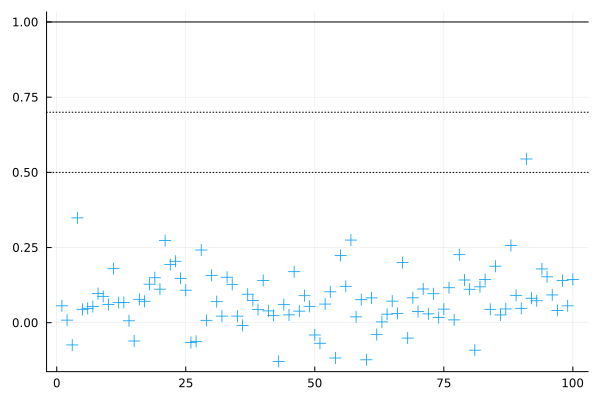

In [11]:
scatter(loo_res.pointwise.pareto_shape; marker=:+, markersize = 6, legend=false, linewidth=2)
hline!([0.5, 0.7], linestyle=:dot, color=:black)
hline!([1.0], linestyle=:solid, color=:black)

### PIT (Probability Integral Transform)

In [12]:
# Clean predictions into (draws, chains, n)
y_pred_array = permutedims(y_pred[[Symbol("y[$i]") for i in 1:n]].value.data, (1, 3, 2))

pitvals_manual = zeros(n)
for i in 1:n
    y_pred_i = y_pred_array[:, :, i] 
    log_w_i = log_weights[:, :, i]
    
    # Identify which draws fall below the observation
    mask = y_pred_i .<= y[i]
    
    # Estimate the CDF as the sum of the weights of those draws
    pitvals_manual[i] = any(mask) ? exp(logsumexp(log_w_i[mask])) : 0.0
end

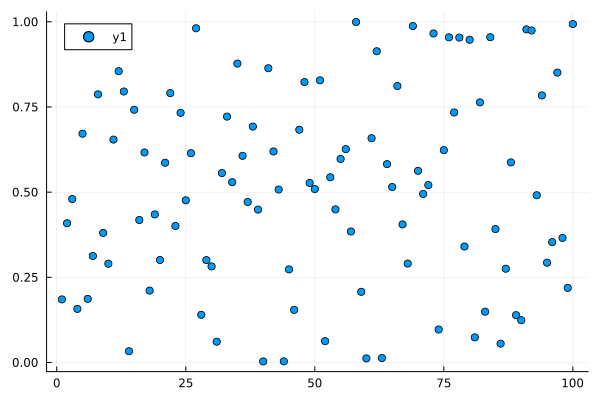

In [13]:
scatter(pitvals_manual)

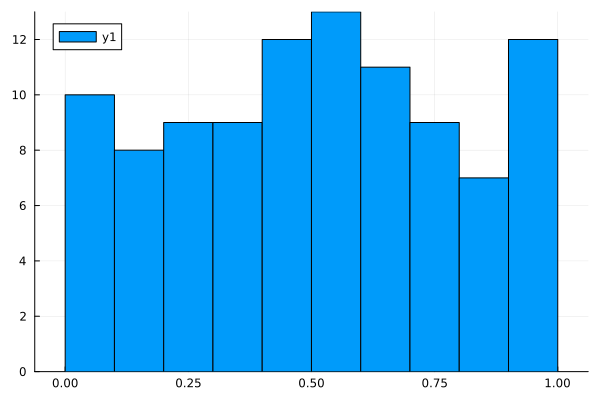

In [14]:
histogram(pitvals_manual, bins=10)

### Comparison of first data point observation and draws

In [15]:
y_pred_array

2000×8×100 Array{Float64, 3}:
[:, :, 1] =
  -9.81773   -9.86023   -9.53843  …   -8.37034   -9.72298  -10.8698
  -9.59014  -11.2634    -9.98215      -9.15977   -8.81979  -10.0559
  -9.79784  -11.318     -9.68713     -11.1563   -10.6198   -10.9067
  -9.2992   -10.0526    -9.2795      -10.355     -9.98834  -10.0526
 -10.3755   -10.6979   -10.8191       -9.08226  -10.0492    -9.74896
  -9.90615   -9.48454  -10.1385   …   -9.37757  -10.6249    -9.57363
 -10.2441   -10.9402   -10.8648       -9.96975  -10.2547   -10.0736
 -10.5556   -11.2717    -8.61369     -10.2186    -9.57058  -10.651
 -10.5465    -8.57924   -9.28432     -11.3273    -9.77297   -9.84204
  -8.79553   -8.74325  -10.9466      -10.0929    -8.88289  -10.9527
 -10.1472   -10.0397   -10.0161   …  -10.8041    -8.58136  -10.9841
 -10.232     -8.4719    -9.37792      -9.97708  -10.6483   -10.476
 -10.9821   -10.2738    -9.7867      -11.5463   -11.0642    -9.3948
   ⋮                              ⋱    ⋮                   
  -9.81232   

In [16]:
y_1_array = []
for i in 1:num_chains
    y_1_array = append!(y_1_array, y_pred_array[:,i,1])
end

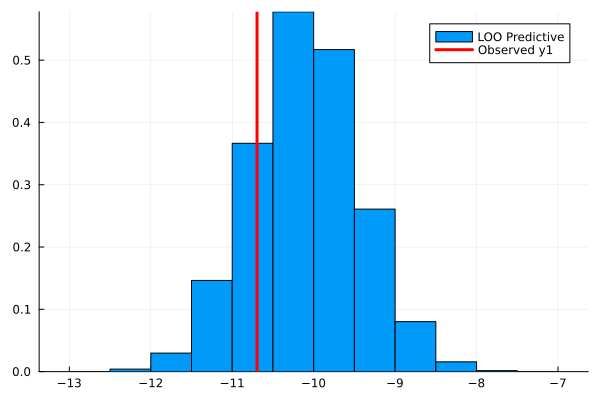

In [17]:
histogram(y_1_array, normalize=:pdf, bins = 20, label="LOO Predictive")
vline!([y[1]], color=:red, linewidth=3, label = "Observed y1")

### Ethan's Manual LOO-PIT

### Comparison of Manual Approaches

In [18]:
# println("Marco Manual LOO-PIT (first 5): ", round.(pitvals_manual[1:5], digits=4))
# println("Ethan Manual LOO-PIT (first 5): ", round.(PIT_Values[1:5], digits=4))

In [19]:
# scatter(PIT_Values, pitvals_manual)
# plot!([0.0, 0.1,0.2,0.3,0.4,0.5,0.6,0.7,0.8,0.9,1.0],[0.0,0.1,0.2,0.3,0.4,0.5,0.6,0.7,0.8,0.9,1.0])

In [20]:
# # Perform the KS test for the Monte Carlo version
ks_test_marco = ExactOneSampleKSTest(pitvals_manual, Uniform(0, 1))

# # Perform the KS test for the Exact Analytic version
# ks_test_ethan = ExactOneSampleKSTest(PIT_Values, Uniform(0, 1))

println("Marco LOO-PIT KS test p-value:    ", pvalue(ks_test_marco))
# println("Ethan LOO-PIT KS test p-value: ", pvalue(ks_test_ethan))

Marco LOO-PIT KS test p-value:    0.7941397125576181
